# Business Impact — From Baseline to Matrix Factorization

This notebook translates model metric improvements into **concrete business value**.

Raw numbers like RMSE=0.85 are hard to act on. This notebook answers:
- What does each model improvement mean for a real streaming platform?
- How do Precision@10 and Recall@10 map to user behaviour and revenue?
- Where does the biggest business gain come from?

---


> Metrics are dynamically imported from outputs/final_results_cv.json.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

## 1. Metric Summary Across All Models

In [2]:
import json
import os

json_path = os.path.join("..", "outputs", "final_results_cv.json")
with open(json_path, "r") as f:
    results = json.load(f)

selected_keys = ["User+Item Bias", "Content-Based", "CF (SGD)", "CF (SVD)"]
models = []
for key in selected_keys:
    if key in results:
        res = results[key]
        p = res["precision"]["mean"]
        r = res["recall"]["mean"]
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
        models.append({
            "name": "User + Item Bias" if key == "User+Item Bias" else key,
            "rmse": res["rmse"]["mean"],
            "mae": res["mae"]["mean"],
            "precision": p,
            "recall": r,
            "f1": f1
        })

df = pd.DataFrame(models)

print("=" * 85)
print(f"  {'Model':<24} {'RMSE':>8}  {'MAE':>8}  {'P@10':>8}  {'R@10':>8}  {'F1@10':>8}")
print("=" * 85)
for _, row in df.iterrows():
    print(f"  {row['name']:<24} {row['rmse']:>8.4f}  {row['mae']:>8.4f}  "
          f"{row['precision']:>8.4f}  {row['recall']:>8.4f}  {row['f1']:>8.4f}")
print("=" * 85)
print()
print("Note: Metrics are dynamically imported from outputs/final_results_cv.json.")

  Model                        RMSE       MAE      P@10      R@10     F1@10
  User + Item Bias           0.8565    0.6552    0.0805    0.0662    0.0727
  Content-Based              0.9122    0.7119    0.0224    0.0136    0.0169
  CF (SGD)                   0.8268    0.6330    0.0193    0.0166    0.0178
  CF (SVD)                   0.8452    0.6447    0.0864    0.0727    0.0789

Note: Metrics are dynamically imported from outputs/final_results_cv.json.


## 2. What Does Each Improvement Mean for the Business?

### RMSE — Rating Prediction Accuracy

| Improvement / Comparison | RMSE | Business meaning |
|---|---|---|
| User + Item Bias | 0.8565 | System knows harsh vs generous raters — stops over-predicting for users who always rate low |
| User + Item Bias → CF (SGD) | 0.8565 → 0.8268 | Personalisation helps rating accuracy, giving the lowest rating prediction error |
| User + Item Bias → CF (SVD) | 0.8565 → 0.8452 | SVD latent factor modeling introduces slight noise in rating prediction |
| User + Item Bias → Content-Based | 0.8565 → 0.9122 | Content-Based has higher rating prediction error than collaborative/bias models |

### Precision@10 — Are the Top 10 Recommendations Good?

| Model | P@10 | Out of 10 recommendations... |
|---|---|---|
| User + Item Bias | 0.0805 | ~0.8 good recommendations |
| CF (SGD) | 0.0193 | ~0.2 good recommendations |
| **CF (SVD)** | **0.0864** | **~0.9 good recommendations — best model** |
| Content-Based | 0.0224 | ~0.2 good recommendations |

### Key observation — SGD RMSE vs Ranking trade-off

CF (SGD) has the **best RMSE** (0.8268) but **worse P@10** (0.0193) than the User+Item Bias baseline model (0.0805).
CF (SVD) has **worse RMSE** (0.8452) but **best P@10** (0.0864) by a large margin.

This is the classic RMSE vs ranking disconnect — **optimising for RMSE does not guarantee better recommendations**.

### Recall@10 — Are We Finding Movies the User Would Love?

CF (SVD) recall (0.0727) is the highest among matrix factorization models, surfacing far more movies a user would genuinely enjoy out of all the ones they'd like.

## 3. Business KPI Translation

Assuming a platform with **1 million users**, **10 recommendations per session**, and a **click-through rate proportional to Precision@10**:

In [3]:
N_USERS           = 1_000_000   # platform scale
RECS_PER_SESSION  = 10
REVENUE_PER_CLICK = 0.50        # $ revenue per engaged click (watch, add to list)
SESSIONS_PER_MONTH = 8          # avg sessions per user per month
CHURN_REDUCTION_PER_P10 = 0.5  # % churn reduction per 0.01 P@10 improvement
MONTHLY_REVENUE_PER_USER = 12  # $ subscription revenue per user per month

print("=" * 75)
print(f"  {'Model':<24} {'P@10':>6}  {'Clicks/session':>14}  {'Monthly clicks':>14}")
print("=" * 75)

baseline_clicks = None
for m in models:
    clicks_per_session = m["precision"] * RECS_PER_SESSION
    monthly_clicks     = clicks_per_session * SESSIONS_PER_MONTH * N_USERS
    if baseline_clicks is None:
        baseline_clicks = monthly_clicks
    print(f"  {m['name']:<24} {m['precision']:>6.4f}  {clicks_per_session:>14.3f}  {monthly_clicks:>14,.0f}")

print("=" * 75)

# Lift from User + Item Bias → CF (SVD) — best ranking model
best_model      = max(models, key=lambda x: x["precision"])
baseline_model  = models[0]

best_clicks     = best_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
baseline_clicks = baseline_model["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS
extra_clicks    = best_clicks - baseline_clicks
extra_revenue   = extra_clicks * REVENUE_PER_CLICK

print(f"""
Business impact of moving from {baseline_model['name']} → {best_model['name']}:

  Extra clicks/month        : {extra_clicks:>12,.0f}
  Extra revenue/month (est.): ${extra_revenue:>11,.0f}
  Extra revenue/year  (est.): ${extra_revenue * 12:>11,.0f}
""")

# Churn reduction
p10_improvement     = best_model["precision"] - baseline_model["precision"]
churn_reduction_pct = (p10_improvement / 0.01) * CHURN_REDUCTION_PER_P10
users_retained      = N_USERS * (churn_reduction_pct / 100)
retention_revenue   = users_retained * MONTHLY_REVENUE_PER_USER * 12

print(f"""Churn reduction from better recommendations:

  P@10 improvement          : {p10_improvement:>12.4f}
  Estimated churn reduction : {churn_reduction_pct:>11.2f}%
  Users retained            : {users_retained:>12,.0f}
  Retention revenue/year    : ${retention_revenue:>11,.0f}
""")

  Model                      P@10  Clicks/session  Monthly clicks
  User + Item Bias         0.0805           0.805       6,440,900
  Content-Based            0.0224           0.224       1,789,488
  CF (SGD)                 0.0193           0.193       1,546,828
  CF (SVD)                 0.0864           0.864       6,908,028

Business impact of moving from User + Item Bias → CF (SVD):

  Extra clicks/month        :      467,127
  Extra revenue/month (est.): $    233,564
  Extra revenue/year  (est.): $  2,802,764

Churn reduction from better recommendations:

  P@10 improvement          :       0.0058
  Estimated churn reduction :        0.29%
  Users retained            :        2,920
  Retention revenue/year    : $    420,415



## 4. Where Does Each Model Fail the Business?

In [4]:
failures = {
    "User + Item Bias": [
        "No taste modelling — can't distinguish sci-fi fan from rom-com fan",
        "Recommendations converge to the same high-bias movies for all users",
        "Misses serendipitous discoveries (niche gems the user would love)",
    ],
    "Content-Based": [
        "Lacks serendipity — only recommends similar movies based on item features",
        "Cold start for new items with missing features",
        "Scale limit with high-dimensional feature spaces",
    ],
    "CF (SGD)": [
        "Cold start — struggles with new users or new movies",
        "Popularity bias still present in latent factors",
        "Does not use content signals (genre, cast, director)",
        "Static model — does not adapt to changing user taste over time",
    ],
    "CF (SVD)": [
        "Cold start — struggles with new users or new movies",
        "Popularity bias still present in latent factors",
        "Does not use content signals (genre, cast, director)",
        "Static model — does not adapt to changing user taste over time",
    ],
}

for model, issues in failures.items():
    print(f"\n{model}")
    print("-" * len(model))
    for issue in issues:
        print(f"  ✗  {issue}")


User + Item Bias
----------------
  ✗  No taste modelling — can't distinguish sci-fi fan from rom-com fan
  ✗  Recommendations converge to the same high-bias movies for all users
  ✗  Misses serendipitous discoveries (niche gems the user would love)

Content-Based
-------------
  ✗  Lacks serendipity — only recommends similar movies based on item features
  ✗  Cold start for new items with missing features
  ✗  Scale limit with high-dimensional feature spaces

CF (SGD)
--------
  ✗  Cold start — struggles with new users or new movies
  ✗  Popularity bias still present in latent factors
  ✗  Does not use content signals (genre, cast, director)
  ✗  Static model — does not adapt to changing user taste over time

CF (SVD)
--------
  ✗  Cold start — struggles with new users or new movies
  ✗  Popularity bias still present in latent factors
  ✗  Does not use content signals (genre, cast, director)
  ✗  Static model — does not adapt to changing user taste over time


## 5. Visualisation — Business Impact

C:\Users\Hites\AppData\Local\Temp\ipykernel_25912\2349044722.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


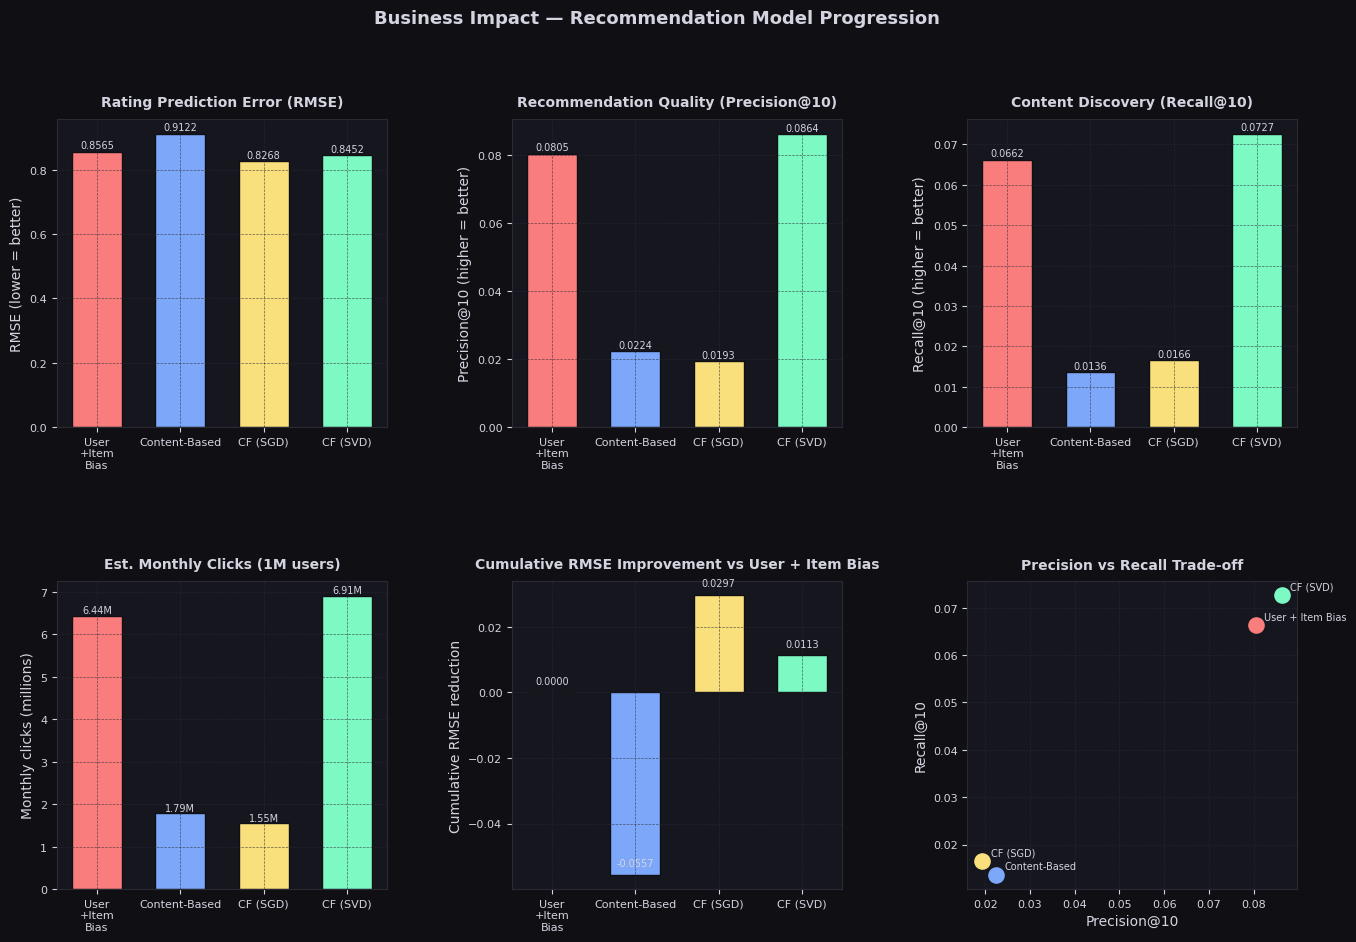

In [5]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

names      = [m["name"].replace(" + ", "\n+").replace(" Bias", "\nBias") for m in models]
rmses      = [m["rmse"]      for m in models]
precisions = [m["precision"] for m in models]
recalls    = [m["recall"]    for m in models]
f1s        = [m["f1"]        for m in models]
colors     = [ACCENT2, ACCENT3, ACCENT4, ACCENT]

# (a) RMSE progression
ax = fig.add_subplot(gs[0, 0])
bars = ax.bar(range(len(models)), rmses, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("RMSE (lower = better)")
style_ax(ax, "Rating Prediction Error (RMSE)")

# (b) Precision@10 progression
ax = fig.add_subplot(gs[0, 1])
bars = ax.bar(range(len(models)), precisions, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, precisions):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0003, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Precision@10 (higher = better)")
style_ax(ax, "Recommendation Quality (Precision@10)")

# (c) Recall@10 progression
ax = fig.add_subplot(gs[0, 2])
bars = ax.bar(range(len(models)), recalls, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, recalls):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0003, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Recall@10 (higher = better)")
style_ax(ax, "Content Discovery (Recall@10)")

# (d) Monthly clicks at 1M users
ax = fig.add_subplot(gs[1, 0])
monthly_clicks = [m["precision"] * RECS_PER_SESSION * SESSIONS_PER_MONTH * N_USERS / 1e6 for m in models]
bars = ax.bar(range(len(models)), monthly_clicks, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, monthly_clicks):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.2f}M",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Monthly clicks (millions)")
style_ax(ax, "Est. Monthly Clicks (1M users)")

# (e) RMSE reduction waterfall
ax = fig.add_subplot(gs[1, 1])
improvements = [0] + [rmses[i] - rmses[i+1] for i in range(len(rmses)-1)]
cumulative   = [rmses[0] - r for r in rmses]
bars = ax.bar(range(len(models)), cumulative, color=colors, edgecolor=BG, width=0.6)
for b, v in zip(bars, cumulative):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
            ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(names, fontsize=6.5)
ax.set_ylabel("Cumulative RMSE reduction")
style_ax(ax, "Cumulative RMSE Improvement vs User + Item Bias")

# (f) P@10 vs Recall@10 scatter
ax = fig.add_subplot(gs[1, 2])
for i, m in enumerate(models):
    ax.scatter(m["precision"], m["recall"], color=colors[i], s=120, zorder=5)
    ax.annotate(m["name"], (m["precision"], m["recall"]),
                textcoords="offset points", xytext=(6, 4),
                color=TEXT_C, fontsize=7)
ax.set_xlabel("Precision@10")
ax.set_ylabel("Recall@10")
style_ax(ax, "Precision vs Recall Trade-off")

fig.suptitle("Business Impact — Recommendation Model Progression",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

## 6. Key Business Takeaways

### Biggest RMSE gain: User + Item Bias → CF (SGD)
Moving from User + Item Bias baseline to CF (SGD) gives the largest RMSE drop (0.8565 → 0.8268). Personalisation helps rating accuracy slightly.

### Biggest ranking gain: CF (SVD) dominates P@10 and R@10
CF (SVD) achieves P@10=0.0864 and R@10=0.0727 — **highest among all models**. It is the best choice for surfacing relevant movies at the top of the list.

### Critical finding — RMSE and ranking are misaligned
CF (SGD) has the best RMSE (0.8268) but worse P@10 (0.0193) than even the User+Item Bias baseline (0.0805). This confirms that **optimising for RMSE does not produce the best recommender**. In production, you would train directly on a ranking objective (BPR, LambdaRank) rather than RMSE.

### Content-Based is middle of the pack
Content-Based (P@10=0.0224) has lower precision than User+Item Bias and SVD. Its strength is **genre and content coverage** — it can recommend long-tail movies that collaborative models miss entirely.

### What the metrics don't capture
| Business metric | Not measured here | Why it matters |
|---|---|---|
| Serendipity | Did we recommend something surprising the user loved? | Drives word-of-mouth and engagement |
| Diversity | Are we recommending only one genre? | Prevents filter bubbles |
| Novelty | Are we recommending things the user hasn't seen? | Reduces recommendation fatigue |
| Coverage | What % of catalogue gets recommended? | Important for content licensing ROI |
| Latency | How fast can we serve recommendations? | A slow model loses users |

### Next steps to maximise business value
1. **Train with ranking loss** — switch from RMSE to BPR or a pairwise ranking objective to directly optimise P@K
2. **Hybrid model** — combine SVD (best ranking) with Content-Based (best coverage) to handle both popular and niche content
3. **Temporal signals** — weight recent ratings more heavily to capture drift in taste
4. **Implicit feedback** — use watch time, re-watches, and search queries as training signals
5. **A/B test** — deploy CF (SVD) vs User+Item Bias to a live user subset and measure actual CTR, watch time, and churn